# Face Cropping dari Video - Iris Short Term 1 (2026)

Notebook ini adalah **tahap pra-pemrosesan (preprocessing)** sebelum training model pengenalan wajah.  
Tujuannya adalah mengekstrak dan memotong wajah secara otomatis dari file video mentah milik setiap orang, lalu menyimpannya sebagai kumpulan gambar yang siap digunakan untuk training.

**Alur kerja secara keseluruhan:**
```
Video mentah (per orang)
        ↓
Ambil frame setiap N frame
        ↓
Deteksi wajah dengan Haar Cascade
        ↓
Crop + resize wajah
        ↓
Simpan sebagai gambar .jpg
        ↓
Zip hasil untuk diunduh / digunakan di training
```

---

## Import Library

Mengimpor tiga library utama yang dibutuhkan:
- **`os`** → operasi file system (buat folder, cek path)
- **`glob`** → pencarian file dengan wildcard (*.mp4, *.jpg, dll.)
- **`cv2` (OpenCV)** → membaca video, deteksi wajah, dan menyimpan gambar

In [1]:
import os
from glob import glob
import cv2

## Konfigurasi Global

Mendefinisikan semua parameter cropping dalam satu tempat:

| Parameter | Nilai | Keterangan |
|---|---|---|
| `DATASET_ROOT` | `/kaggle/input/...` | Folder berisi subfolder tiap orang (video mentah) |
| `OUTPUT_ROOT` | `/kaggle/working/cropped_faces` | Folder output hasil crop |
| `FRAME_INTERVAL` | 2 | Ambil 1 frame setiap 2 frame (50% frame diproses) |
| `MAX_FACES_PER_VIDEO` | 200 | Maksimal 200 gambar wajah per video |
| `FACE_SIZE` | (299, 299) | Ukuran akhir gambar wajah yang disimpan |
| `MARGIN` | 0.4 | Margin ekstra 40% di sekitar area wajah |

> `MARGIN = 0.4` artinya area crop diperlebar 40% ke semua sisi agar kepala, dahi, dan sebagian leher ikut tercakup — tidak hanya wajah saja.

In [2]:
DATASET_ROOT = "/kaggle/input/datasets/iwayansatya/iris-shortterm-1"       
OUTPUT_ROOT = "/kaggle/working/cropped_faces"  

FRAME_INTERVAL = 2          
MAX_FACES_PER_VIDEO = 200   
FACE_SIZE = (299, 299)     
MARGIN = 0.4               

os.makedirs(OUTPUT_ROOT, exist_ok=True)
print("Output folder:", OUTPUT_ROOT)

Output folder: /kaggle/working/cropped_faces


## Load Haar Cascade Face Detector

Memuat model deteksi wajah bawaan OpenCV: **`haarcascade_frontalface_default.xml`**.

Haar Cascade adalah algoritma deteksi objek klasik yang cepat dan ringan, cocok untuk mendeteksi wajah menghadap ke depan (*frontal face*). Model ini sudah disertakan dalam instalasi OpenCV sehingga tidak perlu diunduh terpisah.

Jika gagal dimuat, program akan langsung berhenti dengan pesan error.

In [3]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

if face_cascade.empty():
    raise RuntimeError("Gagal load Haar Cascade face detector")

## Fungsi `crop_faces_from_video()`

Fungsi utama yang memproses **satu file video** dan mengekstrak gambar wajah darinya.

**Langkah-langkah yang dilakukan:**
1. Buka video dengan `cv2.VideoCapture`
2. Baca frame satu per satu; proses hanya setiap `frame_interval` frame
3. Konversi frame ke grayscale, lalu terapkan **CLAHE** (Contrast Limited Adaptive Histogram Equalization) untuk meningkatkan kontras → membantu deteksi wajah di kondisi cahaya kurang baik
4. Jalankan Haar Cascade untuk mendeteksi wajah (`scaleFactor=1.05`, `minNeighbors=3`)
5. Jika ada beberapa wajah, pilih yang **terbesar** (wajah utama/terdekat kamera)
6. Tambahkan **margin** di sekitar bounding box wajah
7. Crop area tersebut, resize ke `FACE_SIZE` (299×299), dan simpan sebagai `.jpg`
8. Berhenti jika sudah mencapai `max_faces`

**Return:** jumlah gambar wajah yang berhasil disimpan

In [4]:
def crop_faces_from_video(
    video_path,
    output_dir,
    frame_interval=2,
    max_faces=500,
    face_size=(299, 299),
    margin=0.4
):
    os.makedirs(output_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"[WARNING] Tidak bisa membuka video: {video_path}")
        return 0

    video_name = os.path.splitext(os.path.basename(video_path))[0]
    frame_idx = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % frame_interval == 0:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            gray = clahe.apply(gray)

            faces = face_cascade.detectMultiScale(
                gray,
                scaleFactor=1.05,
                minNeighbors=3,
                minSize=(20, 20)
            )

            if len(faces) > 0:
                faces = sorted(faces, key=lambda x: x[2] * x[3], reverse=True)
                x, y, w, h = faces[0]

                mx = int(w * margin)
                my = int(h * margin)

                x1 = max(0, x - mx)
                y1 = max(0, y - my)
                x2 = min(frame.shape[1], x + w + mx)
                y2 = min(frame.shape[0], y + h + my)

                face = frame[y1:y2, x1:x2]

                if face.size > 0:
                    face = cv2.resize(face, face_size)

                    save_path = os.path.join(
                        output_dir,
                        f"{video_name}_face_{saved_count:05d}.jpg"
                    )
                    cv2.imwrite(save_path, face)
                    saved_count += 1

                    if saved_count >= max_faces:
                        break

        frame_idx += 1

    cap.release()
    return saved_count

## Fungsi `process_person_folder()`

Fungsi pembungkus (*wrapper*) yang memproses **semua video milik satu orang**.

**Cara kerja:**
1. Baca nama orang dari nama folder (`os.path.basename`)
2. Buat folder output khusus orang tersebut di dalam `OUTPUT_ROOT`
3. Cari semua file video dengan ekstensi `.mp4`, `.avi`, `.mov`, `.mkv`, `.webm`
4. Untuk setiap video, panggil `crop_faces_from_video()`
5. Cetak ringkasan berapa gambar berhasil disimpan per video

**Return:** total gambar wajah dari semua video orang tersebut

In [5]:
def process_person_folder(
    person_dir,
    output_root,
    frame_interval=5,
    max_faces_per_video=200,
    face_size=(160, 160),
    margin=0.2
):
    person_name = os.path.basename(person_dir)
    person_output_dir = os.path.join(output_root, person_name)
    os.makedirs(person_output_dir, exist_ok=True)

    video_paths = []
    for ext in ["*.mp4", "*.avi", "*.mov", "*.mkv", "*.webm"]:
        video_paths.extend(glob(os.path.join(person_dir, ext)))

    total_saved = 0

    print(f"\nProcessing: {person_name}")
    print(f"Jumlah video: {len(video_paths)}")

    for video_path in sorted(video_paths):
        saved = crop_faces_from_video(
            video_path=video_path,
            output_dir=person_output_dir,
            frame_interval=frame_interval,
            max_faces=max_faces_per_video,
            face_size=face_size,
            margin=margin
        )
        print(f"- {os.path.basename(video_path)} -> {saved} face crops")
        total_saved += saved

    print(f"Total saved for {person_name}: {total_saved}")
    return total_saved

## Deteksi Folder Dataset

Memindai `DATASET_ROOT` untuk menemukan semua subfolder yang merepresentasikan satu orang.  
Hasilnya diurutkan secara alfabetis:

```
Ashif / Christo / Devian / Marcell / Naufal / Patrick / Satya
```

Total **7 orang** yang akan diproses.

In [6]:
person_dirs = [d for d in glob(os.path.join(DATASET_ROOT, "*")) if os.path.isdir(d)]
person_dirs = sorted(person_dirs)

print("Daftar folder orang:")
for d in person_dirs:
    print("-", os.path.basename(d))

Daftar folder orang:
- Ashif
- Christo
- Devian
- Marcell
- Naufal
- Patrick
- Satya


## Proses Semua Orang (Loop Utama)

Loop utama yang memanggil `process_person_folder()` untuk setiap orang secara berurutan dan menyimpan hasilnya ke dictionary `summary`.

**Hasil cropping per orang:**
| Orang | Video | Hasil Crop |
|-------|-------|-----------|
| Ashif | 1 | 200 gambar |
| Christo | 1 | 188 gambar |
| Devian | 1 | 198 gambar |
| Marcell | 1 | 190 gambar |
| Naufal | 1 | 89 gambar |
| Patrick | 1 | 105 gambar |
| Satya | 1 | 200 gambar |


In [7]:
summary = {}

for person_dir in person_dirs:
    person_name = os.path.basename(person_dir)
    total = process_person_folder(
        person_dir=person_dir,
        output_root=OUTPUT_ROOT,
        frame_interval=FRAME_INTERVAL,
        max_faces_per_video=MAX_FACES_PER_VIDEO,
        face_size=FACE_SIZE,
        margin=MARGIN
    )
    summary[person_name] = total


Processing: Ashif
Jumlah video: 1
- Ashif.mp4 -> 200 face crops
Total saved for Ashif: 200

Processing: Christo
Jumlah video: 1
- Christo.mp4 -> 188 face crops
Total saved for Christo: 188

Processing: Devian
Jumlah video: 1
- Devian.mp4 -> 198 face crops
Total saved for Devian: 198

Processing: Marcell
Jumlah video: 1
- Marcell.mp4 -> 190 face crops
Total saved for Marcell: 190

Processing: Naufal
Jumlah video: 1
- Naufal.mp4 -> 89 face crops
Total saved for Naufal: 89

Processing: Patrick
Jumlah video: 1
- Patrick.mp4 -> 105 face crops
Total saved for Patrick: 105

Processing: Satya
Jumlah video: 1
- Satya.mp4 -> 200 face crops
Total saved for Satya: 200


## Ringkasan Hasil

Mencetak ringkasan total gambar wajah yang berhasil di-crop per orang.  
Total keseluruhan: **1.170 gambar** dari 7 orang.

In [8]:
print("\n=== Ringkasan ===")
for person_name, total in summary.items():
    print(f"{person_name}: {total} cropped faces")


=== Ringkasan ===
Ashif: 200 cropped faces
Christo: 188 cropped faces
Devian: 198 cropped faces
Marcell: 190 cropped faces
Naufal: 89 cropped faces
Patrick: 105 cropped faces
Satya: 200 cropped faces


## Fungsi Visualisasi Sampel

Fungsi `show_sample_images()` menampilkan pratinjau gambar hasil crop dari sebuah folder.  
Menampilkan hingga **8 gambar** dalam grid 2×4 menggunakan `matplotlib` untuk memverifikasi secara visual bahwa hasil cropping sudah benar (wajah terpotong rapi, tidak terlalu ketat atau terlalu longgar).

In [9]:
import matplotlib.pyplot as plt

def show_sample_images(folder, max_images=8):
    image_paths = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.webp"]:
        image_paths.extend(glob(os.path.join(folder, ext)))

    image_paths = sorted(image_paths)[:max_images]

    if len(image_paths) == 0:
        print("Tidak ada gambar di folder:", folder)
        return

    plt.figure(figsize=(16, 8))
    for i, img_path in enumerate(image_paths):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(os.path.basename(img_path))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Tampilkan Contoh Hasil Crop

Mengambil folder pertama dari hasil output dan menampilkan 8 gambar sampel sebagai verifikasi visual.

Ini penting untuk memastikan pipeline berjalan dengan benar sebelum melanjutkan ke tahap training.

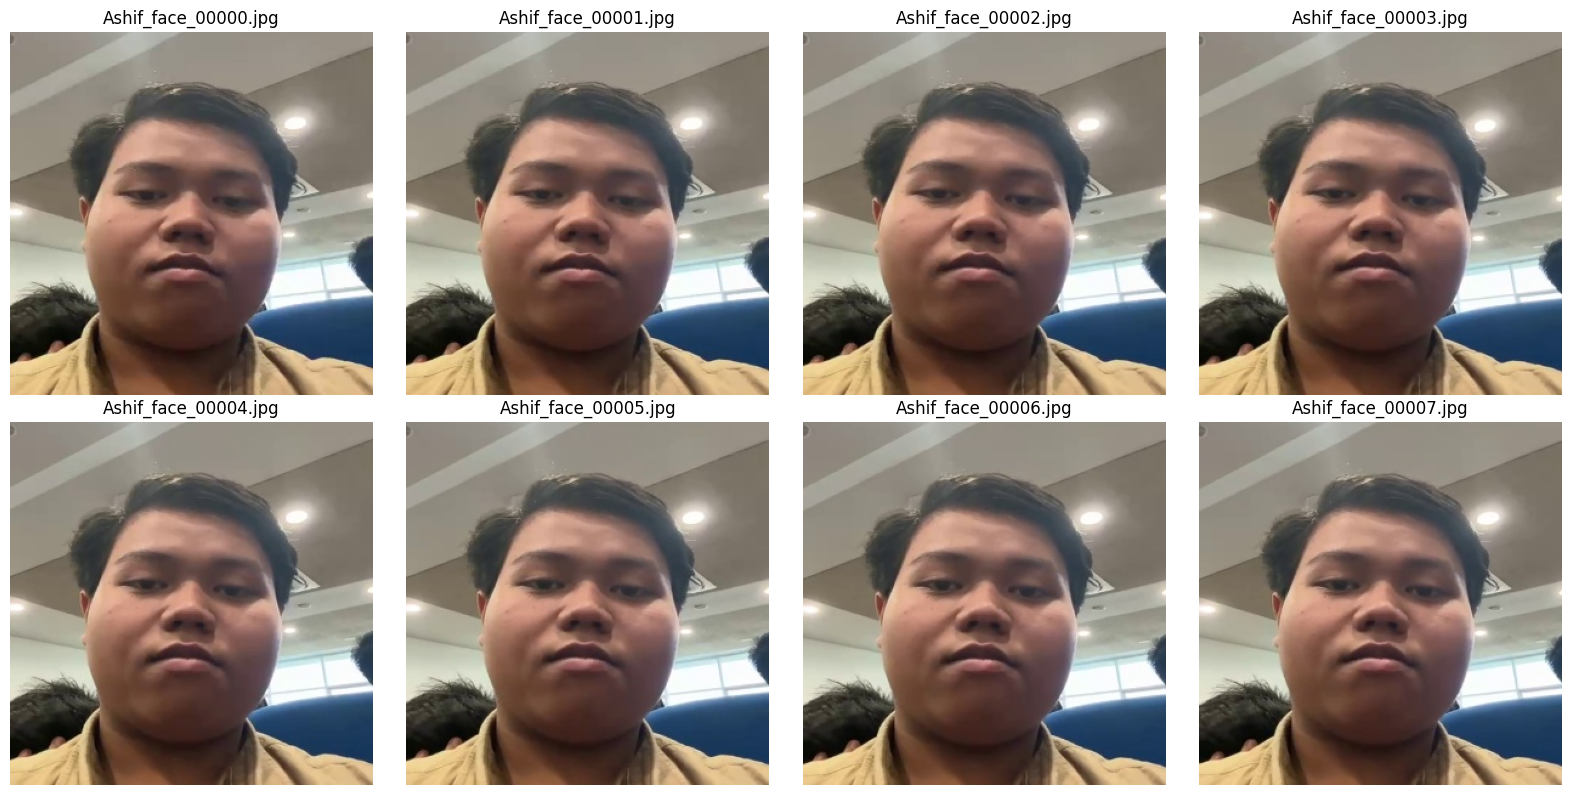

In [10]:
example_person = os.path.join(OUTPUT_ROOT, os.listdir(OUTPUT_ROOT)[0])
show_sample_images(example_person, max_images=8)

## Kompres Hasil ke ZIP

Mengemas seluruh folder `cropped_faces/` menjadi satu file **`cropped_faces.zip`** menggunakan `shutil.make_archive`.

File ZIP ini memudahkan:
- Mengunduh semua hasil crop sekaligus dari Kaggle
- Mengunggah sebagai dataset baru untuk digunakan di notebook training

In [11]:
import shutil

ZIP_BASENAME = "/kaggle/working/cropped_faces"
SOURCE_DIR = OUTPUT_ROOT  

zip_path = shutil.make_archive(
    base_name=ZIP_BASENAME,
    format="zip",
    root_dir=SOURCE_DIR
)

print("ZIP created:", zip_path)

ZIP created: /kaggle/working/cropped_faces.zip
